<a href="https://colab.research.google.com/github/Cynac58/Cynac58/blob/main/Copy_of_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np

# to visualize the dataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#for classification tasks
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.preprocessing import KBinsDiscretizer
#metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score

# ignore warnings
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0120ENv3/Dataset/ML0101EN_EDX_skill_up/cbb.csv")
df.head()

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Villanova,BE,40,35,123.1,90.9,0.9703,56.1,46.7,16.3,...,30.0,57.4,44.1,36.2,33.9,66.7,8.9,Champions,2.0,2016
2,Notre Dame,ACC,36,24,118.3,103.3,0.8269,54.0,49.5,15.3,...,26.0,52.9,46.5,37.4,36.9,65.5,2.3,E8,6.0,2016
3,Virginia,ACC,37,29,119.9,91.0,0.9600,54.8,48.4,15.1,...,33.4,52.6,46.3,40.3,34.7,61.9,8.6,E8,1.0,2016
4,Kansas,B12,37,32,120.9,90.4,0.9662,55.7,45.1,17.8,...,37.3,52.7,43.4,41.3,32.5,70.1,11.6,E8,1.0,2016


In [ ]:
df.describe()

,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
count,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,...,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,272.000000,1406.000000
mean,31.570413,16.724751,103.848720,103.849716,0.493272,50.406757,50.595448,18.458535,18.391821,28.881223,...,34.612233,34.885633,49.486415,49.642745,34.662873,34.830228,69.292461,-7.855121,8.790441,2017.502134
std,2.586927,6.492069,7.250998,6.422037,0.255095,3.042034,2.779066,1.949515,2.082490,4.045938,...,4.798377,5.735014,3.366320,3.211512,2.670789,2.333992,2.771836,7.001387,4.676650,1.119066
min,24.000000,1.000000,82.900000,85.200000,0.026600,40.000000,41.100000,13.500000,10.200000,15.000000,...,21.600000,21.800000,37.700000,38.400000,26.700000,27.500000,60.300000,-25.200000,1.000000,2016.000000
25%,30.000000,12.000000,98.900000,99.225000,0.281400,48.400000,48.800000,17.200000,17.000000,26.200000,...,31.300000,30.700000,47.200000,47.525000,32.800000,33.200000,67.400000,-13.100000,5.000000,2017.000000
50%,31.000000,16.000000,103.400000,104.000000,0.474000,50.400000,50.600000,18.400000,18.300000,29.000000,...,34.500000,34.300000,49.400000,49.600000,34.600000,34.800000,69.200000,-8.450000,9.000000,2018.000000
75%,33.000000,21.000000,108.300000,108.275000,0.711075,52.400000,52.400000,19.700000,19.700000,31.600000,...,37.800000,38.700000,51.600000,51.775000,36.500000,36.400000,71.000000,-3.100000,13.000000,2019.000000
max,40.000000,37.000000,128.400000,124.000000,0.974400,59.800000,59.500000,25.900000,27.600000,42.000000,...,49.400000,58.500000,62.600000,61.200000,43.400000,43.100000,83.400000,11.600000,16.000000,2019.000000


In [ ]:
df.columns

Index(['TEAM', 'CONF', 'G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D',
       'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O',
       '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'YEAR'],
      dtype='object')

In [ ]:
df.shape

(1406, 24)

In [4]:
df=pd.read_csv("https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0120ENv3/Dataset/ML0101EN_EDX_skill_up/cbb.csv")

In [ ]:
if 'POSTSEASON' in df.columns:
    print("\nTarget variable distribution:")
    print(df['POSTSEASON'].value_counts())


Target variable distribution:
POSTSEASON
R64          128
R32           64
S16           32
E8            16
R68           16
F4             8
2ND            4
Champions      4
Name: count, dtype: int64


In [5]:
df.corr(numeric_only=True)

,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
G,1.000000,0.694294,0.610036,-0.606560,0.684179,0.351768,-0.489071,-0.324177,0.070928,0.276452,...,0.093426,-0.277845,0.343096,-0.446854,0.220460,-0.348541,-0.073626,0.665949,-0.605589,0.042113
W,0.694294,1.000000,0.740726,-0.697598,0.808328,0.624627,-0.629084,-0.437440,0.163512,0.315491,...,0.127848,-0.310100,0.586644,-0.542603,0.432303,-0.500085,-0.056288,0.901692,-0.579559,0.073508
ADJOE,0.610036,0.740726,1.000000,-0.541147,0.876854,0.733943,-0.350522,-0.584143,-0.100177,0.289171,...,0.072360,-0.372815,0.637790,-0.346566,0.578285,-0.201922,0.039005,0.852331,-0.803857,-0.016709
ADJDE,-0.606560,-0.697598,-0.541147,1.000000,-0.855484,-0.262971,0.789522,0.220306,-0.229428,-0.274805,...,-0.099570,0.195381,-0.286613,0.722451,-0.132148,0.560496,0.216587,-0.816995,0.699601,-0.018837
BARTHAG,0.684179,0.808328,0.876854,-0.855484,1.000000,0.566685,-0.632959,-0.464304,0.059057,0.316404,...,0.105572,-0.328662,0.526996,-0.593379,0.401678,-0.423502,-0.092839,0.943035,-0.827624,0.001464
EFG_O,0.351768,0.624627,0.733943,-0.262971,0.566685,1.000000,-0.169170,-0.343668,-0.128320,-0.105013,...,-0.077106,-0.403423,0.887056,-0.148363,0.754215,-0.129869,0.039121,0.578435,-0.310675,0.108600
EFG_D,-0.489071,-0.629084,-0.350522,0.789522,-0.632959,-0.169170,1.000000,0.109440,0.002917,-0.311194,...,-0.177110,0.126941,-0.192840,0.901366,-0.076390,0.723797,0.207273,-0.641557,0.385737,0.116721
TOR,-0.324177,-0.437440,-0.584143,0.220306,-0.464304,-0.343668,0.109440,1.000000,0.082966,0.127515,...,0.133536,0.295218,-0.259642,0.097793,-0.315127,0.071761,-0.042741,-0.453637,0.266268,0.064392
TORD,0.070928,0.163512,-0.100177,-0.229428,0.059057,-0.128320,0.002917,0.082966,1.000000,0.107461,...,0.093449,0.380354,-0.066384,0.055925,-0.155566,-0.101289,-0.004097,0.107251,0.080201,0.056249
ORB,0.276452,0.315491,0.289171,-0.274805,0.316404,-0.105013,-0.311194,0.127515,0.107461,1.000000,...,0.261221,0.116237,-0.051205,-0.314253,-0.111172,-0.175745,-0.016860,0.342269,-0.327773,-0.129806


In [ ]:
sns.set_style("whitegrid")

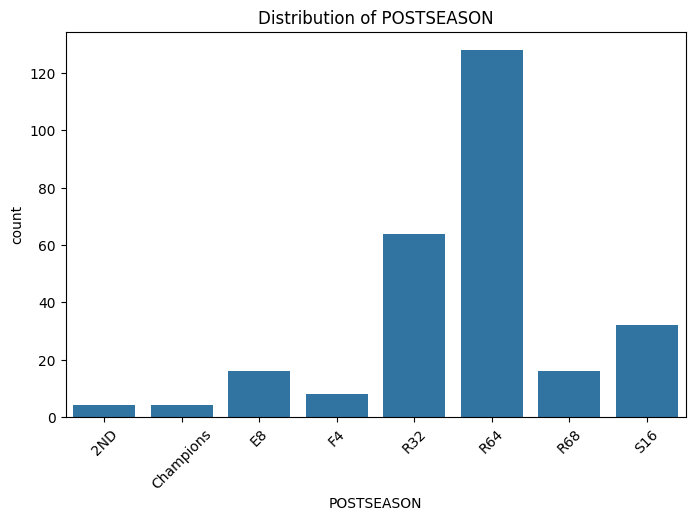

In [6]:
if 'POSTSEASON' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x='POSTSEASON', data=df)
    plt.title("Distribution of POSTSEASON")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
df['MADE_TOURNAMENT'] = df['POSTSEASON'].apply(lambda x: 0 if pd.isna(x) else 1)

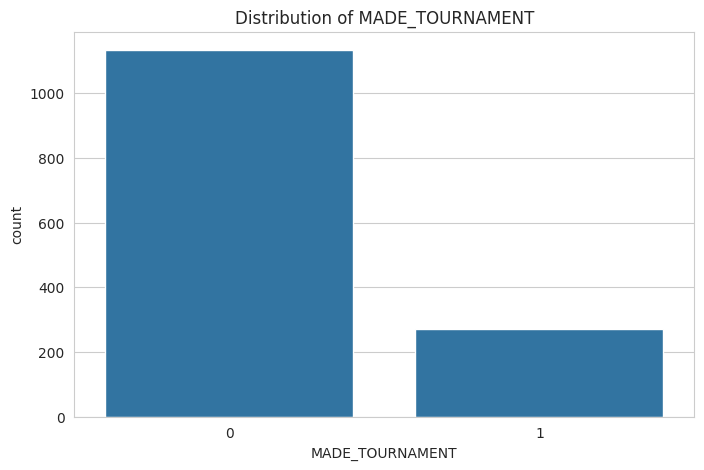


- 0: Teams that DID NOT make the postseason (POSTSEASON = NaN)
- 1: Teams that MADE the postseason (POSTSEASON has any value)


Made Tournament Distribution:
MADE_TOURNAMENT
0    1134
1     272
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
sns.countplot(x='MADE_TOURNAMENT', data=df)
plt.title("Distribution of MADE_TOURNAMENT")
plt.show()

print("\n- 0: Teams that DID NOT make the postseason (POSTSEASON = NaN)")
print("- 1: Teams that MADE the postseason (POSTSEASON has any value)\n")
print("\nMade Tournament Distribution:")
print(df['MADE_TOURNAMENT'].value_counts())

In [ ]:
df.drop('POSTSEASON', axis=1, inplace=True)

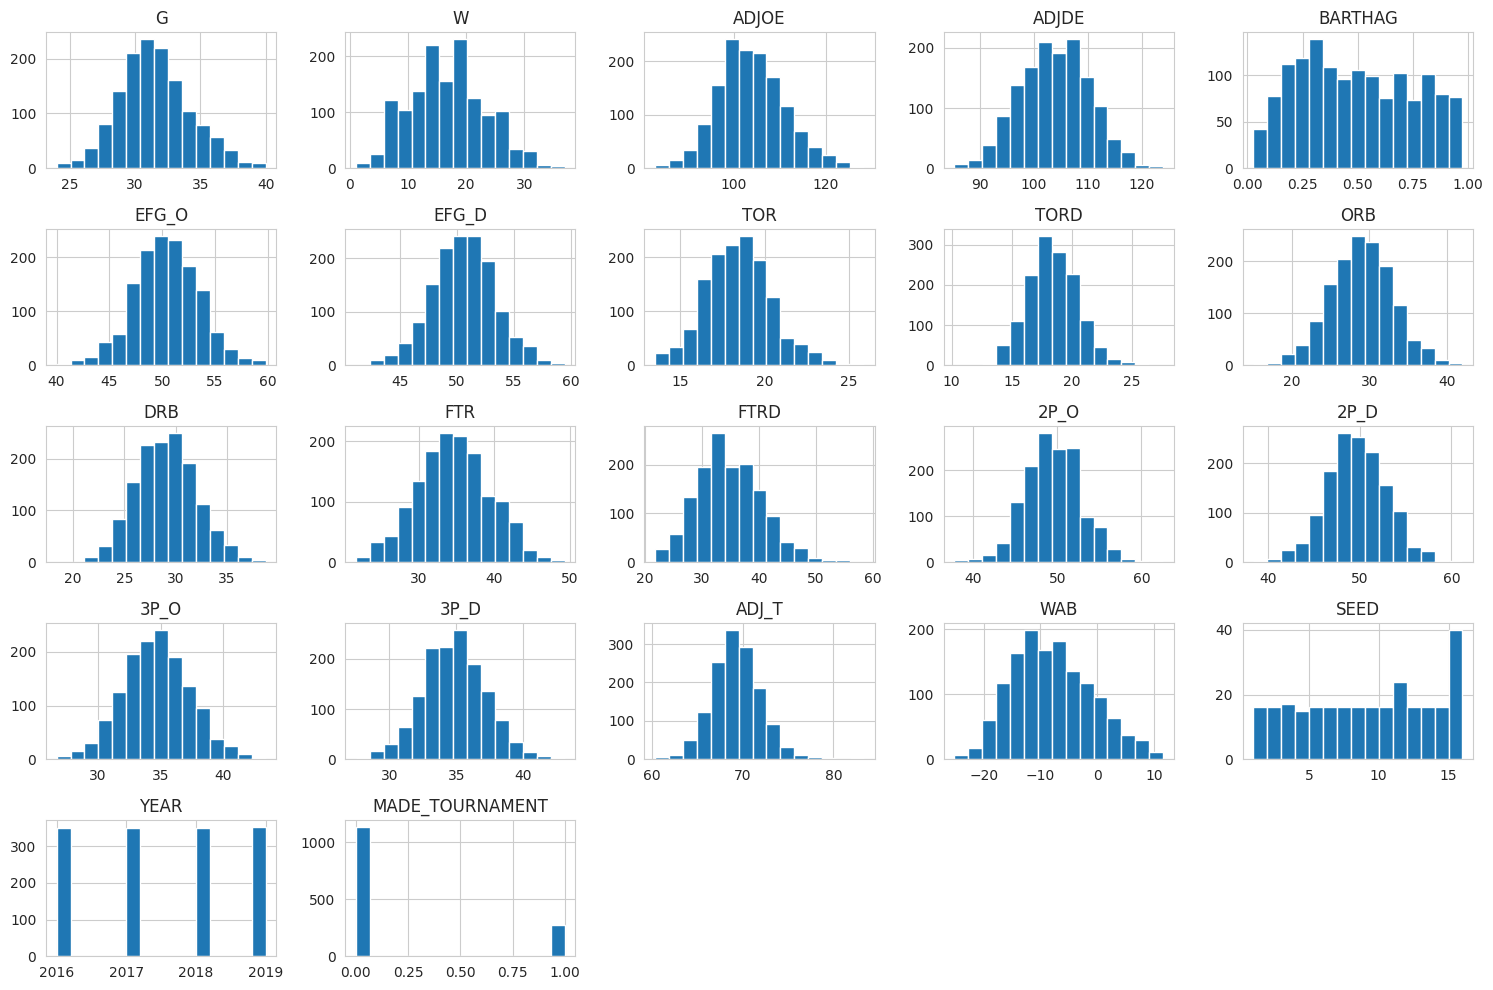

In [ ]:
# Histograms for numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols].hist(bins=15, figsize=(15, 10))
plt.tight_layout()
plt.show()

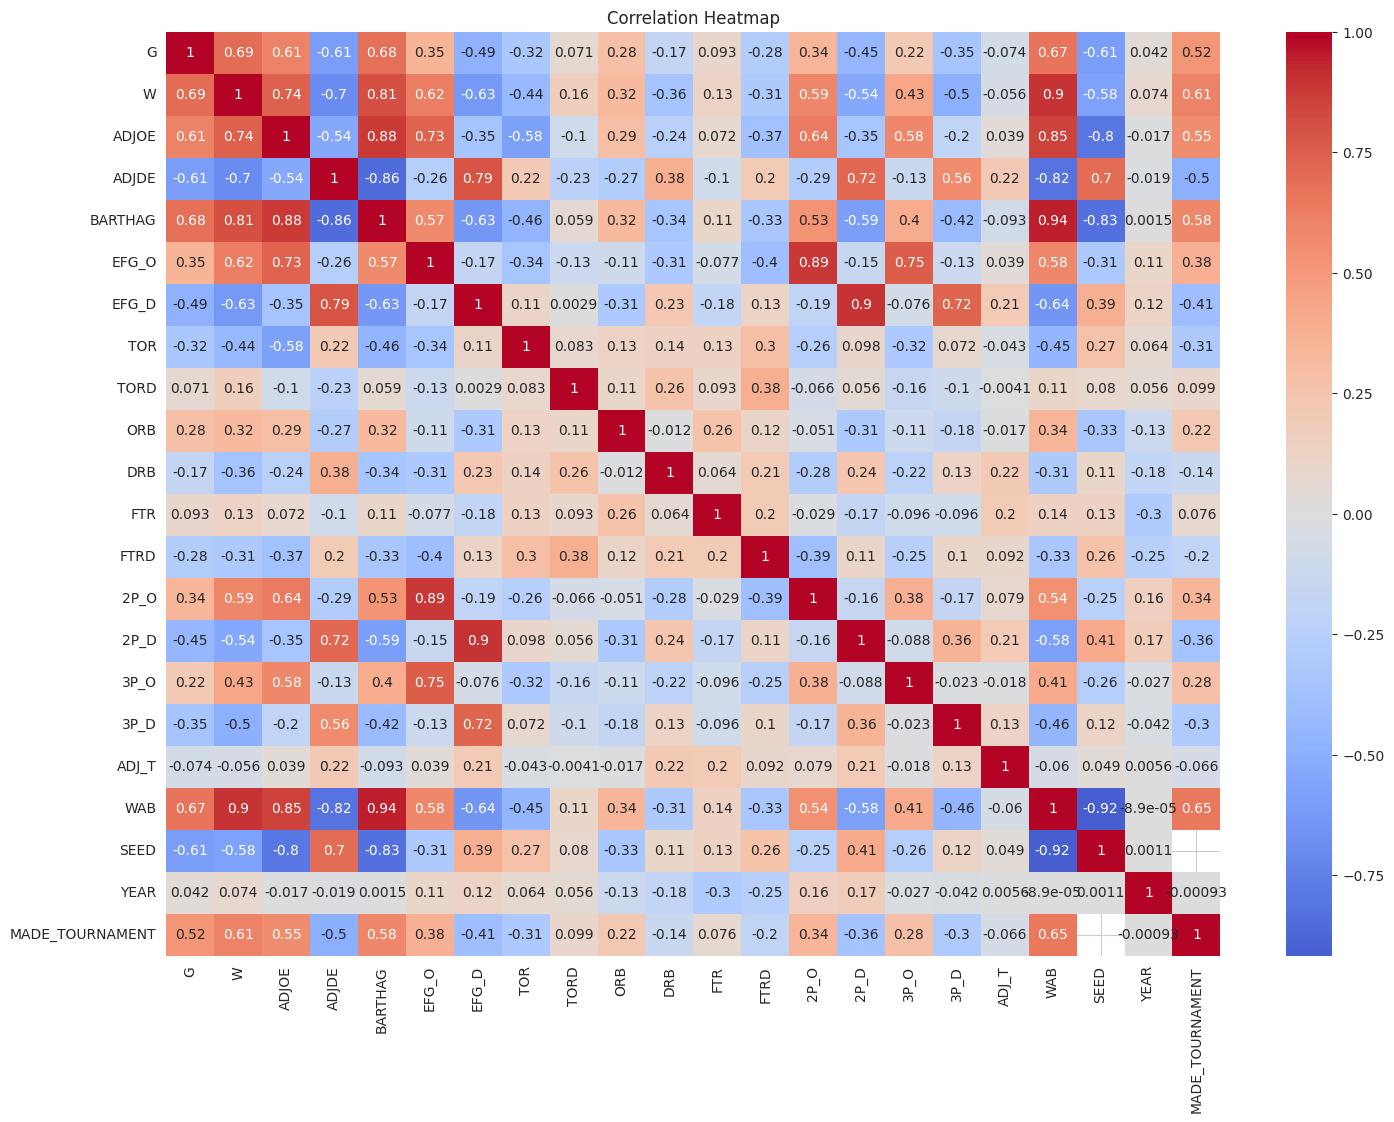

In [ ]:
# Correlation heatmap
plt.figure(figsize=(17, 12))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Missing values before handling:")
df.isnull().sum()

Missing values before handling:


,0
TEAM,0
CONF,0
G,0
W,0
ADJOE,0
ADJDE,0
BARTHAG,0
EFG_O,0
EFG_D,0
TOR,0


In [ ]:
threshold = len(df) * 0.3
df_cleaned = df.dropna(thresh=threshold, axis=1)

In [ ]:
df_cleaned = df_cleaned.dropna()

In [14]:
print("\nMissing values after handling:")
df_cleaned.isnull().sum()



Missing values after handling:


,0
TEAM,0
CONF,0
G,0
W,0
ADJOE,0
ADJDE,0
BARTHAG,0
EFG_O,0
EFG_D,0
TOR,0


In [18]:
# Convert categorical features to numerical (if any)
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
print("\nCategorical columns:", categorical_cols)


Categorical columns: Index(['TEAM', 'CONF'], dtype='object')


In [20]:
label_encoder = LabelEncoder()
for col in categorical_cols:
    if col != 'MADE_TOURNAMENT':
        df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col])

In [22]:
if 'MADE_TOURNAMENT' in df_cleaned.columns:
    df_cleaned['MADE_TOURNAMENT'] = label_encoder.fit_transform(df_cleaned['MADE_TOURNAMENT'])

In [23]:
if 'MADE_TOURNAMENT' in df_cleaned.columns:
    X = df_cleaned.drop('MADE_TOURNAMENT', axis=1)
    y = df_cleaned['MADE_TOURNAMENT']

In [24]:
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

In [25]:
mask = selector.get_support()
selected_features = X.columns[mask]
print("\nSelected features:", selected_features.tolist())


Selected features: ['G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', '2P_O', '2P_D', 'WAB']


In [26]:
data = pd.concat([X[selected_features], y], axis=1)
data.head()

,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,2P_O,2P_D,WAB,MADE_TOURNAMENT
0,40,33,123.3,94.9,0.9531,52.6,48.1,53.9,44.6,8.6,1
1,40,35,123.1,90.9,0.9703,56.1,46.7,57.4,44.1,8.9,1
2,36,24,118.3,103.3,0.8269,54.0,49.5,52.9,46.5,2.3,1
3,37,29,119.9,91.0,0.9600,54.8,48.4,52.6,46.3,8.6,1
4,37,32,120.9,90.4,0.9662,55.7,45.1,52.7,43.4,11.6,1


In [31]:
# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert back to dataframe for visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

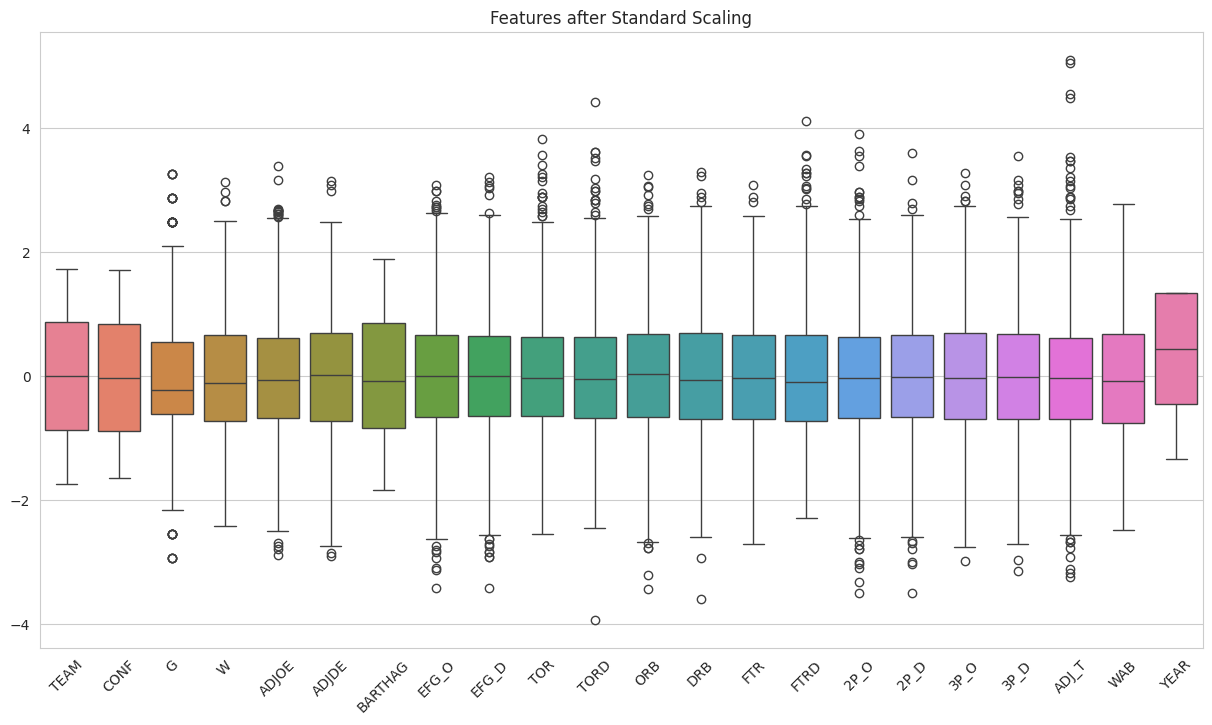

In [32]:
# Show distribution after scaling
plt.figure(figsize=(15, 8))
sns.boxplot(data=X_scaled_df)
plt.title("Features after Standard Scaling")
plt.xticks(rotation=45)
plt.show()

<Axes: >

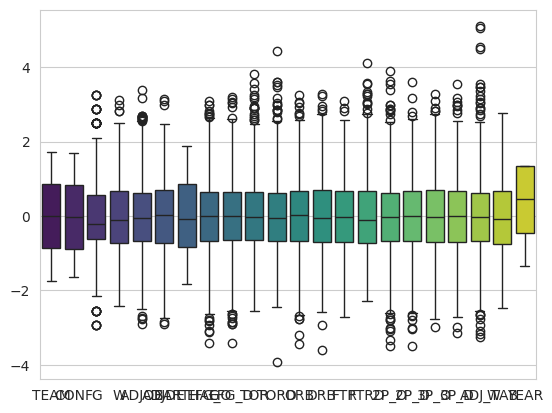

In [40]:
  sns.boxplot(data=X_scaled_df, palette="viridis")  # Example using the "viridis" palette

In [35]:
sns.set_style("whitegrid")  # Example using the "whitegrid" style

In [41]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nClass distribution in testing set:")
print(pd.Series(y_test).value_counts(normalize=True))

Training set shape: (984, 22)
Testing set shape: (422, 22)

Class distribution in training set:
MADE_TOURNAMENT
0    0.806911
1    0.193089
Name: proportion, dtype: float64

Class distribution in testing set:
MADE_TOURNAMENT
0    0.805687
1    0.194313
Name: proportion, dtype: float64


In [42]:
# Initialize models
models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Store results
    results[name] = {
        "model": model,
        "accuracy": accuracy,
        "report": report,
        "confusion_matrix": cm
    }

    # Print results
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report)
    print("\nConfusion Matrix:")
    print(cm)


KNN Results:
Accuracy: 0.8934

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       340
           1       0.77      0.65      0.70        82

    accuracy                           0.89       422
   macro avg       0.84      0.80      0.82       422
weighted avg       0.89      0.89      0.89       422


Confusion Matrix:
[[324  16]
 [ 29  53]]

Decision Tree Results:
Accuracy: 0.8815

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       340
           1       0.68      0.74      0.71        82

    accuracy                           0.88       422
   macro avg       0.81      0.83      0.82       422
weighted avg       0.89      0.88      0.88       422


Confusion Matrix:
[[311  29]
 [ 21  61]]

SVM Results:
Accuracy: 0.9076

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.9


Model Comparison by Accuracy:


,Model,Accuracy
3,Logistic Regression,0.926540
2,SVM,0.907583
0,KNN,0.893365
1,Decision Tree,0.881517


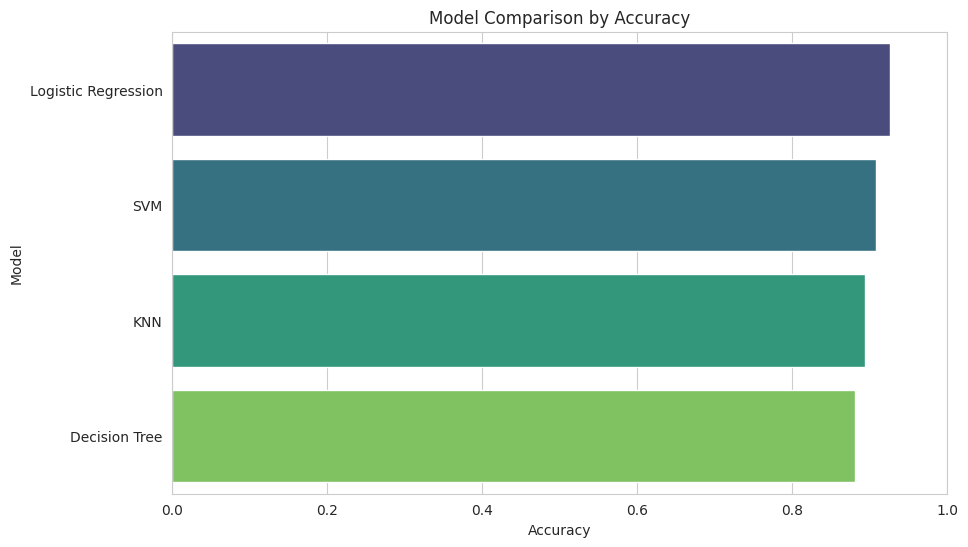

In [43]:
# Create a comparison dataframe
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[name]["accuracy"] for name in results.keys()]
}).sort_values("Accuracy", ascending=False)

print("\nModel Comparison by Accuracy:")
display(comparison_df)

# Visual comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x="Accuracy", y="Model", palette="viridis")
plt.title("Model Comparison by Accuracy")
plt.xlim(0, 1)
plt.show()

In [44]:
print("\nFinal Model Ranking by Accuracy:")
for i, (model, acc) in enumerate(zip(comparison_df['Model'], comparison_df['Accuracy'])):
    print(f"{i+1}. {model}: {acc:.4f} accuracy")

print("\nBest performing model:", comparison_df.iloc[0]['Model'])


Final Model Ranking by Accuracy:
1. Logistic Regression: 0.9265 accuracy
2. SVM: 0.9076 accuracy
3. KNN: 0.8934 accuracy
4. Decision Tree: 0.8815 accuracy

Best performing model: Logistic Regression
